In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_style("whitegrid")

In [2]:
macro_path = './output/ccar_macro_data_quarterly.csv'
df_macro = pd.read_csv(macro_path)
df_macro['DATE'] = pd.to_datetime(df_macro['DATE'])
df_macro.set_index('DATE', inplace=True)
df_macro.index = df_macro.index.to_period('Q')
print(df_macro.describe())
print(df_macro.tail())

       Unemployment_Rate      Real_GDP  BBB_Spread  VIX_Volatility_Index  \
count         104.000000    104.000000  104.000000            104.000000   
mean            5.640545  18273.150202    1.980944             19.834158   
std             1.936582   2847.680659    0.997186              7.394865   
min             3.533333  13878.147000    0.994030             10.307937   
25%             4.166667  16319.276250    1.321654             14.466469   
50%             5.016667  17576.126000    1.751620             17.872615   
75%             6.208333  20463.450500    2.280861             24.013756   
max            13.000000  24111.830000    7.030462             58.604687   

       10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  CPI_Inflation  \
count          104.000000        104.000000  104.000000     104.000000   
mean             3.322854          1.889647    5.102782     233.471003   
std              1.285874          1.933953    2.012014      41.567073   
min              0.

In [3]:
co_path = './output/Fed_CO.csv' 
dr_path = './output/Fed_DR.csv'

df_co = pd.read_csv(co_path)
df_dr = pd.read_csv(dr_path)

df_co['Quarter_dt'] = pd.to_datetime(df_co['Quarter_dt'])
df_co.set_index('Quarter_dt', inplace=True)
df_co.index = df_co.index.to_period('Q')

df_dr['Quarter_dt'] = pd.to_datetime(df_dr['Quarter_dt'])
df_dr.set_index('Quarter_dt', inplace=True)
df_dr.index = df_dr.index.to_period('Q')

df_lgd = df_co.join(df_dr, how='inner')
print(df_lgd.describe())

       Wholesale_Proxy_NCO  Retail_Proxy_NCO  Wholesale_Proxy_DR  \
count           103.000000        103.000000          103.000000   
mean              0.006801          0.044142            0.016971   
std               0.006228          0.018847            0.010495   
min               0.001000          0.015600            0.005800   
25%               0.002700          0.034400            0.010150   
50%               0.004300          0.038600            0.012500   
75%               0.008100          0.050800            0.021300   
max               0.026700          0.106400            0.045400   

       Retail_Proxy_DR  
count       103.000000  
mean          0.033783  
std           0.012476  
min           0.014400  
25%           0.023900  
50%           0.030300  
75%           0.043450  
max           0.068700  


In [4]:
# Calculate Wholesale LGD (CO / DR)
zero_dr_count = (df_lgd['Wholesale_Proxy_DR'] == 0).sum()
print(zero_dr_count)
df_lgd['Wholesale_LGD'] = df_lgd['Wholesale_Proxy_NCO'] / df_lgd['Wholesale_Proxy_DR']
nan_count = df_lgd['Wholesale_LGD'].isna().sum()
print(nan_count)
print(df_lgd['Wholesale_LGD'])

0
0
Quarter_dt
2000Q1    0.308901
2000Q2    0.336538
2000Q3    0.325688
2000Q4    0.413502
2001Q1    0.428571
            ...   
2024Q3    0.522936
2024Q4    0.416667
2025Q1    0.474576
2025Q2    0.491525
2025Q3    0.464000
Freq: Q-DEC, Name: Wholesale_LGD, Length: 103, dtype: float64


In [5]:
df_model = df_lgd[['Wholesale_LGD']].join(df_macro, how='inner')
print(df_model.describe())

       Wholesale_LGD  Unemployment_Rate      Real_GDP  BBB_Spread  \
count     103.000000         103.000000    103.000000  103.000000   
mean        0.359974           5.652104  18216.463990    1.990295   
std         0.130622           1.942443   2802.021705    0.997470   
min         0.090909           3.533333  13878.147000    0.994030   
25%         0.278556           4.166667  16312.271500    1.378204   
50%         0.344444           5.033333  17489.852000    1.760625   
75%         0.451976           6.216667  20368.257500    2.281876   
max         0.643229          13.000000  24026.834000    7.030462   

       VIX_Volatility_Index  10Y_Treasury_Yield  3M_Treasury_Rate  Prime_Rate  \
count            103.000000          103.000000        103.000000  103.000000   
mean              19.854439            3.315309          1.871780    5.084138   
std                7.428119            1.289846          1.934765    2.012805   
min               10.307937            0.650625       

In [6]:
candidate_macros = [
    # Levels (raw series)
    'Unemployment_Rate','Real_GDP','Nominal_GDP','Corporate_Profits','House_Price_Index',
    'Stock_Market_Index','CPI_Inflation','Real_Disposable_Income','Industrial_Production','Capacity_Utilization',

    # Credit conditions (levels)
    'BBB_Spread','HY_Spread','AAA_Spread','AA_Spread',

    # Financial stress (levels)
    'VIX_Volatility_Index','NFCI_Financial_Conditions','STLFSI_Financial_Stress',

    # Rates (levels)
    '10Y_Treasury_Yield','3M_Treasury_Rate','Prime_Rate',

    # Transforms
    'Real_GDP_Growth','Nominal_GDP_Growth','Corp_Profits_YoY','HPI_YoY','Stock_Market_Return',
    'CPI_YoY','RDI_YoY','RDI_Growth','INDPRO_YoY','INDPRO_Growth','TCU_Change',
    'Term_Spread_10Y_3M','10Y_Change','3M_Change','Prime_Change','BBB_Change','HY_Change',
]

lags_to_test = [1, 2, 3, 4]

available_macros = [m for m in candidate_macros if m in df_model.columns]
missing_macros = [m for m in candidate_macros if m not in df_model.columns]
print("Available macros:", len(available_macros))
print("Missing macros (ignored):", missing_macros)

lagged_cols = {}

# LGD lags
for lag in lags_to_test:
    lagged_cols[f"LGD_Lag{lag}"] = df_model["Wholesale_LGD"].shift(lag)

# Macro lags
for m in available_macros:
    for lag in lags_to_test:
        lagged_cols[f"{m}_Lag{lag}"] = df_model[m].shift(lag)

df_lags = pd.DataFrame(lagged_cols, index=df_model.index)

df_model = pd.concat([df_model, df_lags], axis=1)
df_model = df_model.dropna().copy() 

df_model.to_csv("./output/wholesale_lgd_model_candidates.csv")
print("Saved:", df_model.shape)

Available macros: 37
Missing macros (ignored): []
Saved: (99, 190)


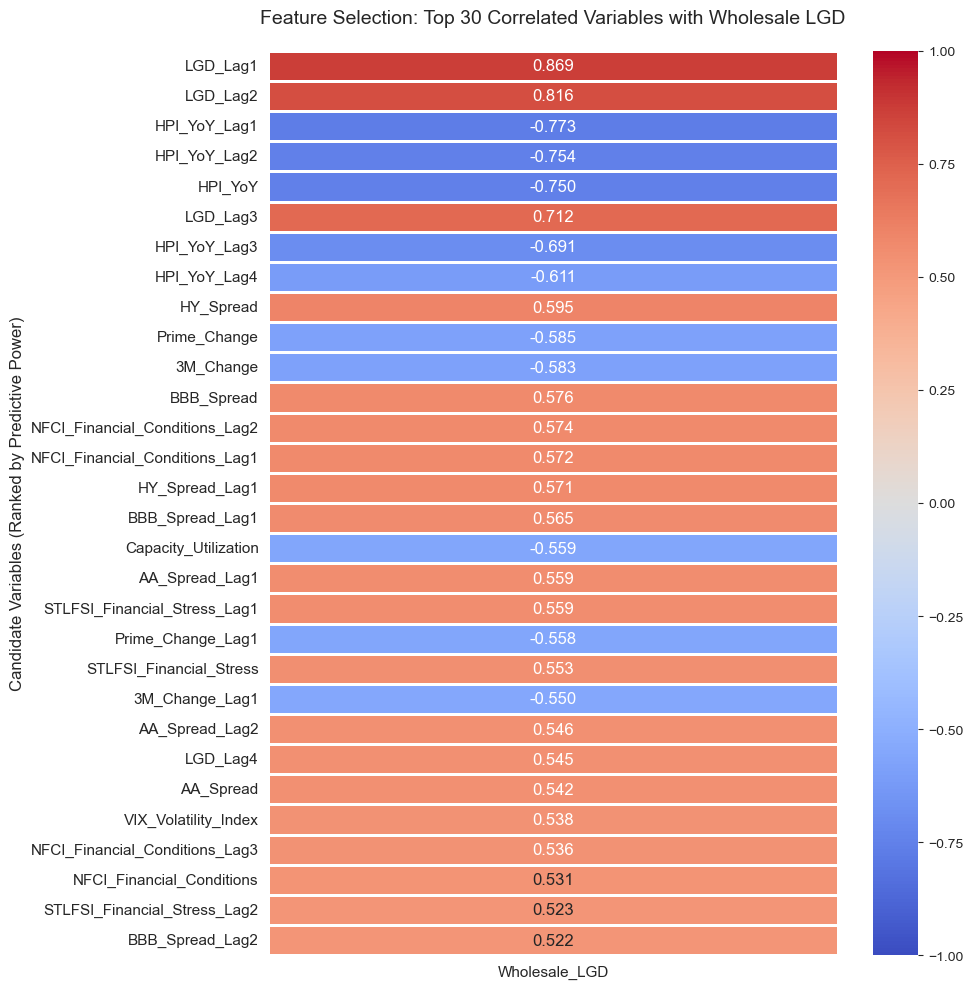

In [7]:
plt.figure(figsize=(10, 10))

target = 'Wholesale_LGD'

corr_with_lgd = df_model.corr()[[target]].drop(target)
corr_with_lgd['Absolute_Corr'] = corr_with_lgd[target].abs()
corr_with_lgd_sorted = corr_with_lgd.sort_values(by='Absolute_Corr', ascending=False)
corr_with_lgd_sorted.drop(columns=['Absolute_Corr'], inplace=True)

top_30_features = corr_with_lgd_sorted.head(30)

sns.heatmap(top_30_features, annot=True, annot_kws={"size": 12}, 
            cmap='coolwarm', fmt=".3f", linewidths=1, vmin=-1, vmax=1)

plt.title('Feature Selection: Top 30 Correlated Variables with Wholesale LGD', fontsize=14, pad=20)
plt.ylabel('Candidate Variables (Ranked by Predictive Power)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.savefig('./output/chart_for_presentation/chart_lgd_wholesale_feature_selection.png', dpi=600, bbox_inches='tight')
plt.show()

In [8]:
top30_names = corr_with_lgd_sorted.head(30).index.tolist()

def base_name(x):
    return re.sub(r"_Lag\d+$", "", x)

shortlist = []
seen = set()
for v in top30_names:
    b = base_name(v)
    if b not in seen:
        shortlist.append(v)
        seen.add(b)

print("Top30:", top30_names)
print("Shortlist (dedup by base):", shortlist)

Top30: ['LGD_Lag1', 'LGD_Lag2', 'HPI_YoY_Lag1', 'HPI_YoY_Lag2', 'HPI_YoY', 'LGD_Lag3', 'HPI_YoY_Lag3', 'HPI_YoY_Lag4', 'HY_Spread', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'NFCI_Financial_Conditions_Lag1', 'HY_Spread_Lag1', 'BBB_Spread_Lag1', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'Prime_Change_Lag1', 'STLFSI_Financial_Stress', '3M_Change_Lag1', 'AA_Spread_Lag2', 'LGD_Lag4', 'AA_Spread', 'VIX_Volatility_Index', 'NFCI_Financial_Conditions_Lag3', 'NFCI_Financial_Conditions', 'STLFSI_Financial_Stress_Lag2', 'BBB_Spread_Lag2']
Shortlist (dedup by base): ['LGD_Lag1', 'HPI_YoY_Lag1', 'HY_Spread', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'VIX_Volatility_Index']


In [9]:
def drop_high_corr_features(df, cols, threshold=0.95, prefer_keep=None, verbose=False):
    """
    Drop one feature from any pair with |corr| > threshold.
    prefer_keep: set/list of column names you prefer to keep if conflict.
    """
    prefer_keep = set(prefer_keep or [])
    X = df[cols].dropna()
    corr = X.corr().abs()

    to_drop = set()
    cols_order = list(corr.columns)

    for i in range(len(cols_order)):
        for j in range(i+1, len(cols_order)):
            a, b = cols_order[i], cols_order[j]
            if corr.loc[a, b] > threshold:

                if a in prefer_keep and b not in prefer_keep:
                    drop = b
                elif b in prefer_keep and a not in prefer_keep:
                    drop = a
                else:
                    drop = b

                to_drop.add(drop)

                if verbose:
                    print(f"High corr |{a} vs {b}| = {corr.loc[a,b]:.3f} -> drop {drop}")

    kept = [c for c in cols if c not in to_drop]
    return kept, sorted(to_drop), corr

# Prefer-keep rules(family-based): prefer by base name (more robust)
prefer_keep_base = {
    "3M_Change": True,      # prefer keeping 3M_Change over Prime_Change: policy rate proxy
    "BBB_Spread": True,     # prefer BBB over AA/HY if extreme corr occurs: corporate credit proxy
}

# Convert base preferences to exact names present in shortlist
prefer_keep = set()
for col in shortlist:
    base = base_name(col)
    if prefer_keep_base.get(base, False):  # only keep if explicitly marked True
        prefer_keep.add(col)

kept, dropped, corr_abs = drop_high_corr_features(
    df_model,
    shortlist,
    threshold=0.95,
    prefer_keep=prefer_keep,
    verbose=True
)

print("\nDropped due to extreme correlation:", dropped)
print("Kept:", kept)

High corr |HY_Spread vs BBB_Spread| = 0.962 -> drop HY_Spread

Dropped due to extreme correlation: ['HY_Spread']
Kept: ['LGD_Lag1', 'HPI_YoY_Lag1', 'Prime_Change', '3M_Change', 'BBB_Spread', 'NFCI_Financial_Conditions_Lag2', 'Capacity_Utilization', 'AA_Spread_Lag1', 'STLFSI_Financial_Stress_Lag1', 'VIX_Volatility_Index']


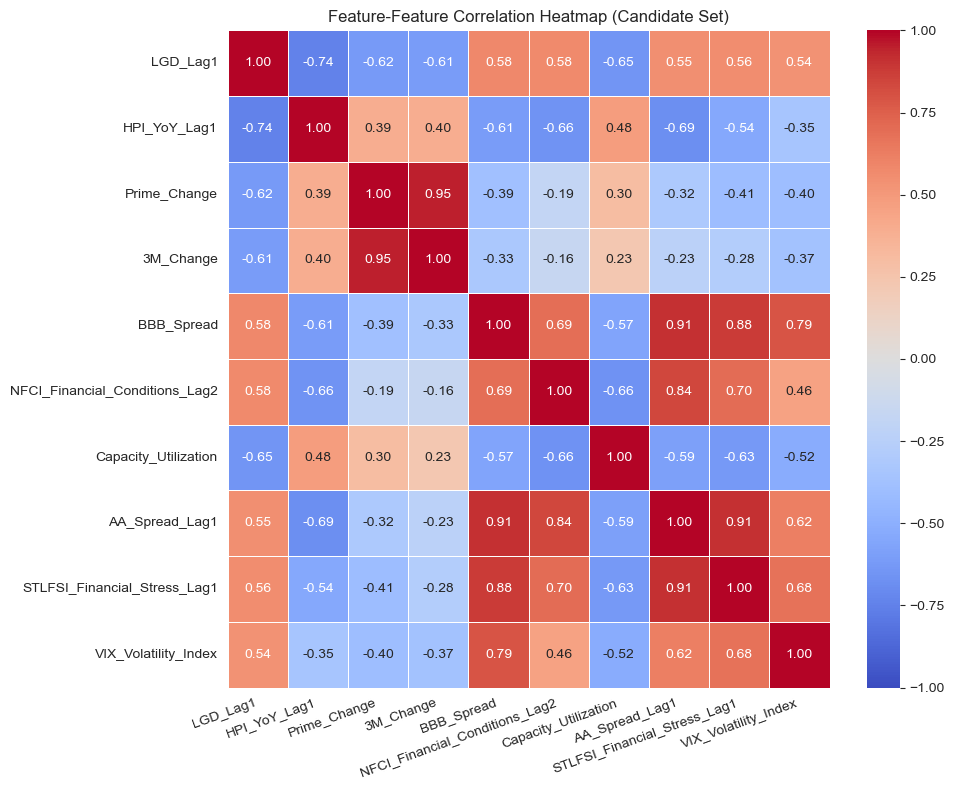

In [10]:
# Build Feature–Feature Corr Heatmap to avoid multicollinearity
df_sub = df_model[kept].dropna().copy()

corr = df_sub.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Feature-Feature Correlation Heatmap (Candidate Set)")
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./output/chart_for_presentation/chart_lgd_wholesale_feature_candidate_correlation_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

In [11]:
# Build VIF (Variance Inflation Factor) table to see collinearity
# VIF = 1: almost no collinearity 
# VIF around 5: begins to raise red flags 
# VIF > 10: severe collinearity (coefficients are unstable, t-values/p-values are distorted, and signs are prone to being confused)
X = df_sub.copy()
X = sm.add_constant(X)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_table = vif_table[vif_table["Variable"] != "const"].sort_values("VIF", ascending=False)
print(vif_table)

                          Variable        VIF
8                   AA_Spread_Lag1  28.502022
3                     Prime_Change  15.336069
4                        3M_Change  14.673677
5                       BBB_Spread  14.084555
9     STLFSI_Financial_Stress_Lag1  10.601675
6   NFCI_Financial_Conditions_Lag2   6.405518
1                         LGD_Lag1   5.253612
2                     HPI_YoY_Lag1   4.505676
10            VIX_Volatility_Index   3.877816
7             Capacity_Utilization   2.751524


In [12]:
# Build the specification step-by-step, adding one candidate at a time and selecting the final model based on incremental fit (Adj-R2/AIC) and economic sign validity.
target = "Wholesale_LGD"

# Candidate set (after collinearity thinking)
CORE = ["LGD_Lag1", "HPI_YoY_Lag1"]

# Rate proxies
RATE_3M  = "3M_Change"
RATE_PRIME = "Prime_Change"

# Credit / stress proxies
CREDIT_BBB   = "BBB_Spread"
CREDIT_AA    = "AA_Spread_Lag1"  # usually very collinear with BBB
STRESS_NFCI  = "NFCI_Financial_Conditions_Lag2"
STRESS_STLFSI = "STLFSI_Financial_Stress_Lag1"
STRESS_VIX   = "VIX_Volatility_Index"


# Real activity
REAL_CAP = "Capacity_Utilization"

# Expected sign map (economic logic)
expected_sign = {
    "LGD_Lag1": +1,
    "HPI_YoY_Lag1": -1,

    # rates: tightening often worsens credit -> LGD up (negative)
    "3M_Change": -1,
    "Prime_Change": -1,

    # spreads/stress: stress up -> LGD up (positive)
    "BBB_Spread": +1,
    "AA_Spread_Lag1": +1,
    "NFCI_Financial_Conditions_Lag2": +1,
    "STLFSI_Financial_Stress_Lag1": +1,
    "VIX_Volatility_Index": +1,

    # capacity utilization: strong economy -> better recoveries -> LGD down (negative)
    "Capacity_Utilization": -1,
}

# Model specs
model_specs = {
    # Core build
    "M0: LGD_Lag1": ["LGD_Lag1"],
    "M1: + HPI_YoY_Lag1": CORE,

    # Rate channel showdown (pick one)
    "M2a: + 3M_Change (on top of Core)": CORE + [RATE_3M],
    "M2b: + Prime_Change (on top of Core)": CORE + [RATE_PRIME],

    # Stress/credit proxy showdown (on top of Core + 3M_Change baseline)
    "M3a: + BBB_Spread (on top of M2a)": CORE + [RATE_3M, CREDIT_BBB],
    "M3b: + NFCI_Lag2 (on top of M2a)": CORE + [RATE_3M, STRESS_NFCI],
    "M3c: + STLFSI_Lag1 (on top of M2a)": CORE + [RATE_3M, STRESS_STLFSI],
    "M3d: + VIX (on top of M2a)": CORE + [RATE_3M, STRESS_VIX],
    "M3e: + AA_Spread_Lag1 (on top of M2a) [optional]": CORE + [RATE_3M, CREDIT_AA],

    # Real economy add-on (on top of each stress proxy)
    "M4a: + Capacity (on top of M3a)": CORE + [RATE_3M, CREDIT_BBB, REAL_CAP],
    "M4b: + Capacity (on top of M3b)": CORE + [RATE_3M, STRESS_NFCI, REAL_CAP],
    "M4c: + Capacity (on top of M3c)": CORE + [RATE_3M, STRESS_STLFSI, REAL_CAP],
    "M4d: + Capacity (on top of M3d)": CORE + [RATE_3M, STRESS_VIX, REAL_CAP],

    # Limited combinations (avoid stacking highly correlated stress proxies too much)
    "M5a: + BBB + VIX (on top of M2a)": CORE + [RATE_3M, CREDIT_BBB, STRESS_VIX],
    "M5b: + NFCI + VIX (on top of M2a)": CORE + [RATE_3M, STRESS_NFCI, STRESS_VIX],
}

ordered_models = list(model_specs.keys())

# sign check table
def sign_check_table(res, expected_sign):
    coef_table = pd.DataFrame({
        "coef": res.params,
        "t": res.tvalues,
        "p": res.pvalues
    })

    def flag(v):
        if v not in expected_sign:
            return ""
        exp = expected_sign[v]
        act = 1 if coef_table.loc[v, "coef"] > 0 else -1
        return "OK" if act == exp else "WRONG"

    coef_table["sign_check"] = ""
    for v in coef_table.index:
        if v in expected_sign:
            coef_table.loc[v, "sign_check"] = flag(v)

    return coef_table

# Build common-sample dataframe (use all variables that appear in any model)

all_X = sorted(set([x for xs in model_specs.values() for x in xs]))
df_common = df_model[[target] + all_X].dropna().copy()

def fit_model(df, y, X_cols):
    y_vec = df[y]
    X = sm.add_constant(df[X_cols])
    return sm.OLS(y_vec, X).fit()

rows = []
prev_res = None

for name in ordered_models:
    X_cols = model_specs[name]
    res = fit_model(df_common, target, X_cols)

    print("\n" + "="*95)
    print(name, "| X =", X_cols)
    print(sign_check_table(res, expected_sign).round(4))
    print(f"R2={res.rsquared:.4f} | Adj_R2={res.rsquared_adj:.4f} | AIC={res.aic:.3f} | BIC={res.bic:.3f} | N={int(res.nobs)}")
    print("="*95)

    row = {
        "Model": name,
        "N": int(res.nobs),
        "R2": res.rsquared,
        "Adj_R2": res.rsquared_adj,
        "AIC": res.aic,
        "BIC": res.bic,
    }

    if prev_res is None:
        row["ΔAdj_R2_vs_prev"] = np.nan
        row["ΔAIC_vs_prev"] = np.nan
    else:
        row["ΔAdj_R2_vs_prev"] = res.rsquared_adj - prev_res.rsquared_adj
        row["ΔAIC_vs_prev"] = res.aic - prev_res.aic

    rows.append(row)
    prev_res = res

summary = pd.DataFrame(rows)
print("\n\nMODEL COMPARISON (narrative order, common sample):")
print(summary.round(6))


M0: LGD_Lag1 | X = ['LGD_Lag1']
            coef        t      p sign_check
const     0.0469   2.4288  0.017           
LGD_Lag1  0.8713  17.3203  0.000         OK
R2=0.7557 | Adj_R2=0.7531 | AIC=-255.037 | BIC=-249.847 | N=99

M1: + HPI_YoY_Lag1 | X = ['LGD_Lag1', 'HPI_YoY_Lag1']
                coef       t       p sign_check
const         0.1498  4.7906  0.0000           
LGD_Lag1      0.6614  9.4322  0.0000         OK
HPI_YoY_Lag1 -0.5458 -4.0196  0.0001         OK
R2=0.7909 | Adj_R2=0.7865 | AIC=-268.437 | BIC=-260.651 | N=99

M2a: + 3M_Change (on top of Core) | X = ['LGD_Lag1', 'HPI_YoY_Lag1', '3M_Change']
                coef       t       p sign_check
const         0.1788  5.1652  0.0000           
LGD_Lag1      0.5832  7.1932  0.0000         OK
HPI_YoY_Lag1 -0.5750 -4.2585  0.0000         OK
3M_Change    -0.0327 -1.8534  0.0669         OK
R2=0.7982 | Adj_R2=0.7918 | AIC=-269.953 | BIC=-259.573 | N=99

M2b: + Prime_Change (on top of Core) | X = ['LGD_Lag1', 'HPI_YoY_Lag1', 'Pr

In [13]:
final_cols = ["LGD_Lag1", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
df_tmp = df_model[[target] + final_cols].dropna().copy()
y = df_tmp[target]
X = sm.add_constant(df_tmp[final_cols])

res = sm.OLS(y, X).fit()

print("\n" + "="*90)
print("FINAL MODEL (OLS) summary (standard SE):")
print(res.summary())
print("="*90)

# 1) Residual autocorrelation checks
dw = durbin_watson(res.resid)
print(f"\nDurbin-Watson: {dw:.3f}  (≈2 means no strong AR(1) autocorrelation)")

# Ljung-Box for multiple lags (quarterly: try 4 and 8)
lb = acorr_ljungbox(res.resid, lags=[4, 8], return_df=True)
print("\nLjung-Box test (residual autocorrelation):")
print(lb)

# 2) HAC (Newey-West) robust standard errors
# Quarterly data: maxlags=4 is a common default (one year)
res_hac = res.get_robustcov_results(cov_type="HAC", maxlags=4)

hac_table = pd.DataFrame({
    "coef": res_hac.params,
    "t(HAC)": res_hac.tvalues,
    "p(HAC)": res_hac.pvalues,
})
print("\n" + "="*90)
print("FINAL MODEL with Newey-West (HAC, maxlags=4) robust inference:")
print(hac_table.round(6))
print("="*90)


FINAL MODEL (OLS) summary (standard SE):
                            OLS Regression Results                            
Dep. Variable:          Wholesale_LGD   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     98.56
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           9.15e-33
Time:                        18:05:42   Log-Likelihood:                 141.32
No. Observations:                  99   AIC:                            -272.6
Df Residuals:                      94   BIC:                            -259.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

In [14]:
# Compute VIF
df_vif = df_model[final_cols].dropna().copy()
X = sm.add_constant(df_vif)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print("VIF (Variance Inflation Factor) Check")
print(vif_table.round(3))

VIF (Variance Inflation Factor) Check
               Variable     VIF
0                 const  33.589
1              LGD_Lag1   3.550
2          HPI_YoY_Lag1   2.292
3             3M_Change   1.630
4  VIX_Volatility_Index   1.419


In [15]:
# Forecast
# scenario data
scenario = pd.read_csv("./raw_data/2026_Final_Supervisory_Severely_Adverse_Domestic.csv").copy()

scenario["Date"] = scenario["Date"].astype(str).str.replace(" ", "", regex=False)
scenario["Date"] = pd.PeriodIndex(scenario["Date"], freq="Q")

# Rename columns to match model inputs
scenario = scenario.rename(columns={
    "House Price Index (Level)": "House_Price_Index",
    "3-month Treasury rate": "ThreeM_Rate",
    "Market Volatility Index (Level)": "VIX_Volatility_Index"
})
print(scenario.head())


                  Scenario Name    Date  Real GDP growth  Nominal GDP growth  \
0  Supervisory Severely Adverse  2026Q1             -5.4                -3.1   
1  Supervisory Severely Adverse  2026Q2             -4.9                -3.3   
2  Supervisory Severely Adverse  2026Q3             -3.8                -2.9   
3  Supervisory Severely Adverse  2026Q4             -2.7                -1.9   
4  Supervisory Severely Adverse  2027Q1             -1.4                -0.5   

   Real disposable income growth  Nominal disposable income growth  \
0                           -0.9                               1.4   
1                           -1.1                               0.5   
2                           -0.7                               0.2   
3                           -0.3                               0.5   
4                            0.3                               1.2   

   Unemployment rate  CPI inflation rate  ThreeM_Rate  5-year Treasury yield  \
0                5

In [16]:
# Build model features exactly as in training
scenario["HPI_YoY"] = scenario["House_Price_Index"].pct_change(4)
scenario["HPI_YoY_Lag1"] = scenario["HPI_YoY"].shift(1)
scenario["3M_Change"] = scenario["ThreeM_Rate"].diff(1)

# Set last ACTUAL historical LGD and forecast 2025Q4 using actual 2025Q3 LGD
last_actual_q3_lgd = df_model.loc[pd.Period("2025Q3", freq="Q"), "Wholesale_LGD"]
q_bridge = pd.Period("2025Q4", freq="Q")

if "HPI_YoY" not in df_macro.columns:
    df_macro["HPI_YoY"] = df_macro["House_Price_Index"].pct_change(4)

if "3M_Change" not in df_macro.columns:
    df_macro["3M_Change"] = df_macro["3M_Treasury_Rate"].diff(1)

if "HPI_YoY_Lag1" not in df_macro.columns:
    df_macro["HPI_YoY_Lag1"] = df_macro["HPI_YoY"].shift(1)

hpi_lag1_q4 = df_macro.loc[q_bridge, "HPI_YoY_Lag1"]
d3m_q4 = df_macro.loc[q_bridge, "3M_Change"]
vix_q4 = df_macro.loc[q_bridge, "VIX_Volatility_Index"]

b0 = res.params["const"]
b1 = res.params["LGD_Lag1"]
b2 = res.params["HPI_YoY_Lag1"]
b3 = res.params["3M_Change"]
b4 = res.params["VIX_Volatility_Index"]

lgd_2025q4_hat = (
    b0
    + b1 * last_actual_q3_lgd
    + b2 * hpi_lag1_q4
    + b3 * d3m_q4
    + b4 * vix_q4
)
print({
    "const": b0,
    "LGD_Lag1": b1,
    "HPI_YoY_Lag1": b2,
    "3M_Change": b3,
    "VIX_Volatility_Index": b4
})
print("Actual 2025Q3 LGD:", round(last_actual_q3_lgd, 6))
print("Bridge inputs for 2025Q4:")
print({
    "HPI_YoY_Lag1_2025Q4": float(hpi_lag1_q4),
    "3M_Change_2025Q4": float(d3m_q4),
    "VIX_2025Q4": float(vix_q4)
})
print("Predicted 2025Q4 LGD (bridge quarter):", round(lgd_2025q4_hat, 6))

{'const': 0.16379836520473418, 'LGD_Lag1': 0.5168448601784503, 'HPI_YoY_Lag1': -0.5975807844698824, '3M_Change': -0.03068314631946382, 'VIX_Volatility_Index': 0.0020311565948262153}
Actual 2025Q3 LGD: 0.464
Bridge inputs for 2025Q4:
{'HPI_YoY_Lag1_2025Q4': 0.0147797897447781, '3M_Change_2025Q4': -0.3666666666666667, 'VIX_2025Q4': 17.74523076923077}
Predicted 2025Q4 LGD (bridge quarter): 0.442076


In [17]:
# historical macro tail for feature engineering
macro_tail = df_macro.loc[
    (df_macro.index >= pd.Period("2024Q1", freq="Q")) &
    (df_macro.index <= pd.Period("2025Q4", freq="Q")),
    ["House_Price_Index", "3M_Treasury_Rate", "VIX_Volatility_Index"]
].copy()

macro_tail = macro_tail.reset_index().rename(columns={
    macro_tail.reset_index().columns[0]: "Date",
    "3M_Treasury_Rate": "ThreeM_Rate"
})

scenario_small = scenario[["Date", "House_Price_Index", "ThreeM_Rate", "VIX_Volatility_Index"]].copy()

scenario_full = pd.concat([macro_tail, scenario_small], ignore_index=True)
scenario_full = scenario_full.sort_values("Date").reset_index(drop=True)

# build model features exactly as in training
scenario_full["HPI_YoY"] = scenario_full["House_Price_Index"].pct_change(4)
scenario_full["HPI_YoY_Lag1"] = scenario_full["HPI_YoY"].shift(1)
scenario_full["3M_Change"] = scenario_full["ThreeM_Rate"].diff(1)

# projection window
proj = scenario_full.loc[
    (scenario_full["Date"] >= pd.Period("2026Q1", freq="Q")) &
    (scenario_full["Date"] <= pd.Period("2029Q1", freq="Q")),
    ["Date", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
].copy()

print(proj.head())


      Date  HPI_YoY_Lag1  3M_Change  VIX_Volatility_Index
8   2026Q1      0.013674      -1.23                  59.7
9   2026Q2     -0.069156      -2.40                  72.0
10  2026Q3     -0.144359       0.00                  70.9
11  2026Q4     -0.172259       0.00                  66.6
12  2027Q1     -0.198164       0.00                  62.3


In [18]:
# Forecast 2026Q1 to 2029Q1 recursively
preds = []
prev_lgd = lgd_2025q4_hat

for _, row in proj.iterrows():
    q = row["Date"]
    hpi = row["HPI_YoY_Lag1"]
    d3m = row["3M_Change"]
    vix = row["VIX_Volatility_Index"]

    lgd_hat = (
        b0
        + b1 * prev_lgd
        + b2 * hpi
        + b3 * d3m
        + b4 * vix
    )

    preds.append({
        "Quarter": q,
        "LGD_Lag1_used": prev_lgd,
        "HPI_YoY_Lag1": hpi,
        "3M_Change": d3m,
        "VIX": vix,
        "Pred_Wholesale_LGD": lgd_hat
    })

    prev_lgd = lgd_hat

forecast_lgd = pd.DataFrame(preds)

print("\nForecast LGD path:")
print(forecast_lgd.round(6))


Forecast LGD path:
   Quarter  LGD_Lag1_used  HPI_YoY_Lag1  3M_Change   VIX  Pred_Wholesale_LGD
0   2026Q1       0.442076      0.013674      -1.23  59.7            0.543112
1   2026Q2       0.543112     -0.069156      -2.40  72.0            0.705712
2   2026Q3       0.705712     -0.144359       0.00  70.9            0.758817
3   2026Q4       0.758817     -0.172259       0.00  66.6            0.794203
4   2027Q1       0.794203     -0.198164       0.00  62.3            0.819238
5   2027Q2       0.819238     -0.163036       0.00  58.1            0.802655
6   2027Q3       0.802655     -0.137006       0.00  53.8            0.769795
7   2027Q4       0.769795     -0.136946       0.00  49.5            0.744041
8   2028Q1       0.744041     -0.136070       0.00  45.3            0.721677
9   2028Q2       0.721677     -0.089905       0.00  41.0            0.673796
10  2028Q3       0.673796     -0.040507       0.00  36.7            0.610796
11  2028Q4       0.610796      0.010607       0.00  32.5

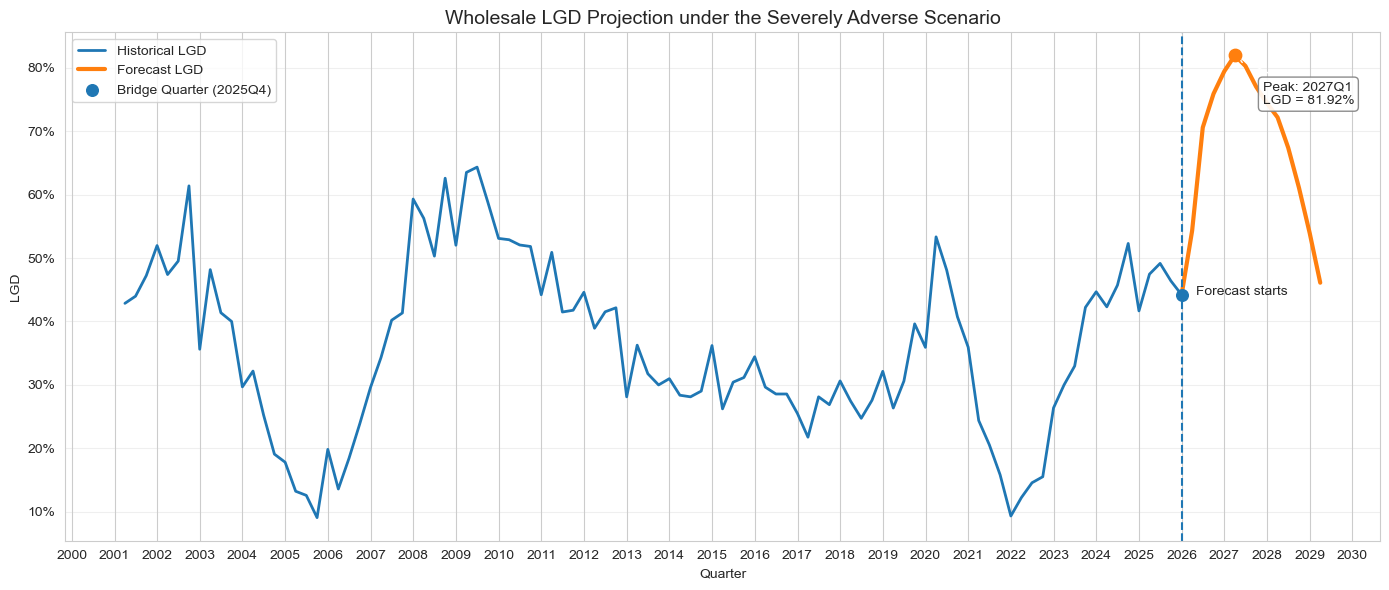

In [19]:
# Historical + Forecast LGD plot

hist = df_model[["Wholesale_LGD"]].copy().reset_index()
hist = hist.rename(columns={hist.columns[0]: "Quarter"})
hist["Quarter"] = hist["Quarter"].astype(str)

# convert quarter string to quarter-end date
hist["Date"] = hist["Quarter"].str.replace("Q1", "-03-31") \
                             .str.replace("Q2", "-06-30") \
                             .str.replace("Q3", "-09-30") \
                             .str.replace("Q4", "-12-31")
hist["Date"] = pd.to_datetime(hist["Date"])

# Bridge quarter (2025Q4)
bridge_df = pd.DataFrame({
    "Quarter": ["2025Q4"],
    "Wholesale_LGD": [lgd_2025q4_hat],
    "Date": [pd.Timestamp("2025-12-31")]
})

# Forecast path
fcst_plot = forecast_lgd.copy()
fcst_plot["Quarter"] = fcst_plot["Quarter"].astype(str)
fcst_plot["Date"] = fcst_plot["Quarter"].str.replace("Q1", "-03-31") \
                                      .str.replace("Q2", "-06-30") \
                                      .str.replace("Q3", "-09-30") \
                                      .str.replace("Q4", "-12-31")
fcst_plot["Date"] = pd.to_datetime(fcst_plot["Date"])
fcst_plot = fcst_plot.rename(columns={"Pred_Wholesale_LGD": "Wholesale_LGD"})

# Split actual vs forecast
actual_cutoff = pd.Timestamp("2025-09-30")
forecast_start = pd.Timestamp("2025-12-31")

actual_part = hist[hist["Date"] <= actual_cutoff].copy()

# extend historical line to bridge quarter
historical_extended = pd.concat(
    [actual_part, bridge_df[["Date", "Quarter", "Wholesale_LGD"]]],
    ignore_index=True
)

# forecast line starts from bridge quarter
forecast_part = pd.concat(
    [bridge_df[["Date", "Quarter", "Wholesale_LGD"]],
     fcst_plot[["Date", "Quarter", "Wholesale_LGD"]]],
    ignore_index=True
)

# peak forecast point
peak_idx = forecast_part["Wholesale_LGD"].idxmax()
peak_row = forecast_part.loc[peak_idx]


# Plot
plt.figure(figsize=(14, 6))

# historical actual + bridge
plt.plot(
    historical_extended["Date"],
    historical_extended["Wholesale_LGD"],
    label="Historical LGD",
    linewidth=2
)

# forecast path
plt.plot(
    forecast_part["Date"],
    forecast_part["Wholesale_LGD"],
    label="Forecast LGD",
    linewidth=3
)

# bridge point
plt.scatter(
    bridge_df["Date"],
    bridge_df["Wholesale_LGD"],
    s=70,
    zorder=5,
    label="Bridge Quarter (2025Q4)"
)

# forecast start line
plt.axvline(
    x=forecast_start,
    linestyle="--",
    linewidth=1.5
)

# annotate peak
plt.scatter(
    peak_row["Date"],
    peak_row["Wholesale_LGD"],
    s=80,
    zorder=6
)

plt.annotate(
    f"Peak: {peak_row['Quarter']}\nLGD = {peak_row['Wholesale_LGD']:.2%}",
    xy=(peak_row["Date"], peak_row["Wholesale_LGD"]),
    xytext=(20, -35),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1)
)

# annotate forecast start
plt.annotate(
    "Forecast starts",
    xy=(forecast_start, bridge_df["Wholesale_LGD"].iloc[0]),
    xytext=(10, 0),
    textcoords="offset points",
    fontsize=10
)

# formatting
plt.title("Wholesale LGD Projection under the Severely Adverse Scenario", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("LGD")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# # Put the full LGD forecasting workflow into a reusable function so we can run it for different scenarios.
def run_lgd_scenario(
    scenario_path,
    scenario_name,
    df_model,
    df_macro,
    res,
    target="Wholesale_LGD",
    start_proj="2026Q1",
    end_proj="2029Q1",
    last_actual_q3_period="2025Q3",
    bridge_period="2025Q4",
):

    # 1) Read scenario
    scenario = pd.read_csv(scenario_path).copy()
    scenario["Date"] = scenario["Date"].astype(str).str.replace(" ", "", regex=False)
    scenario["Date"] = pd.PeriodIndex(scenario["Date"], freq="Q")

    scenario = scenario.rename(columns={
        "House Price Index (Level)": "House_Price_Index",
        "3-month Treasury rate": "ThreeM_Rate",
        "Market Volatility Index (Level)": "VIX_Volatility_Index"
    })

    scenario = scenario[["Date", "House_Price_Index", "ThreeM_Rate", "VIX_Volatility_Index"]].copy()

    # 2) Historical macro tail
    macro_tail = df_macro.loc[
        (df_macro.index >= pd.Period("2024Q1", freq="Q")) &
        (df_macro.index <= pd.Period("2025Q4", freq="Q")),
        ["House_Price_Index", "3M_Treasury_Rate", "VIX_Volatility_Index"]
    ].copy()

    macro_tail = macro_tail.reset_index().rename(columns={
        macro_tail.reset_index().columns[0]: "Date",
        "3M_Treasury_Rate": "ThreeM_Rate"
    })

    scenario_full = pd.concat([macro_tail, scenario], ignore_index=True)
    scenario_full = scenario_full.sort_values("Date").reset_index(drop=True)

    # 3) Build features exactly as in training
    scenario_full["HPI_YoY"] = scenario_full["House_Price_Index"].pct_change(4)
    scenario_full["HPI_YoY_Lag1"] = scenario_full["HPI_YoY"].shift(1)
    scenario_full["3M_Change"] = scenario_full["ThreeM_Rate"].diff(1)

    # 4) Last actual LGD and bridge quarter
    last_actual_q3_lgd = df_model.loc[pd.Period(last_actual_q3_period, freq="Q"), target]
    q_bridge = pd.Period(bridge_period, freq="Q")

    hpi_lag1_q4 = scenario_full.loc[scenario_full["Date"] == q_bridge, "HPI_YoY_Lag1"].iloc[0]
    d3m_q4 = scenario_full.loc[scenario_full["Date"] == q_bridge, "3M_Change"].iloc[0]
    vix_q4 = scenario_full.loc[scenario_full["Date"] == q_bridge, "VIX_Volatility_Index"].iloc[0]

    b0 = res.params["const"]
    b1 = res.params["LGD_Lag1"]
    b2 = res.params["HPI_YoY_Lag1"]
    b3 = res.params["3M_Change"]
    b4 = res.params["VIX_Volatility_Index"]

    lgd_2025q4_hat = (
        b0
        + b1 * last_actual_q3_lgd
        + b2 * hpi_lag1_q4
        + b3 * d3m_q4
        + b4 * vix_q4
    )

    # 5) Projection window
    proj = scenario_full.loc[
        (scenario_full["Date"] >= pd.Period(start_proj, freq="Q")) &
        (scenario_full["Date"] <= pd.Period(end_proj, freq="Q")),
        ["Date", "HPI_YoY_Lag1", "3M_Change", "VIX_Volatility_Index"]
    ].copy()

    # 6) Recursive forecast
    preds = []
    prev_lgd = lgd_2025q4_hat

    for _, row in proj.iterrows():
        q = row["Date"]
        hpi = row["HPI_YoY_Lag1"]
        d3m = row["3M_Change"]
        vix = row["VIX_Volatility_Index"]

        lgd_hat = (
            b0
            + b1 * prev_lgd
            + b2 * hpi
            + b3 * d3m
            + b4 * vix
        )

        preds.append({
            "Scenario": scenario_name,
            "Quarter": q,
            "LGD_Lag1_used": prev_lgd,
            "HPI_YoY_Lag1": hpi,
            "3M_Change": d3m,
            "VIX": vix,
            "Pred_Wholesale_LGD": lgd_hat
        })
        prev_lgd = lgd_hat

    forecast_lgd = pd.DataFrame(preds)

    print(f"\n===== {scenario_name}: Bridge + Forecast =====")
    print("Bridge quarter LGD (2025Q4):", round(lgd_2025q4_hat, 6))
    print(forecast_lgd.round(6))

    return scenario_full, forecast_lgd, lgd_2025q4_hat

In [21]:
baseline_path = "./raw_data/2026_Final_Supervisory_Baseline_Domestic.csv"

scenario_full_base, forecast_lgd_base, lgd_2025q4_hat_base = run_lgd_scenario(
    scenario_path=baseline_path,
    scenario_name="Baseline",
    df_model=df_model,
    df_macro=df_macro,
    res=res
)


===== Baseline: Bridge + Forecast =====
Bridge quarter LGD (2025Q4): 0.442076
    Scenario Quarter  LGD_Lag1_used  HPI_YoY_Lag1  3M_Change   VIX  \
0   Baseline  2026Q1       0.442076      0.013674      -0.13  23.0   
1   Baseline  2026Q2       0.434817     -0.002491      -0.20  22.0   
2   Baseline  2026Q3       0.440842     -0.015650      -0.20  21.9   
3   Baseline  2026Q4       0.451617     -0.011014      -0.10  22.1   
4   Baseline  2027Q1       0.451753     -0.004334       0.00  22.5   
5   Baseline  2027Q2       0.445575      0.007083       0.00  22.9   
6   Baseline  2027Q3       0.436372      0.004604       0.00  23.2   
7   Baseline  2027Q4       0.433707      0.003371       0.00  23.5   
8   Baseline  2028Q1       0.433675      0.002755       0.00  23.8   
9   Baseline  2028Q2       0.434636      0.002446      -0.10  24.1   
10  Baseline  2028Q3       0.438995      0.002750       0.00  24.3   
11  Baseline  2028Q4       0.438405      0.003665       0.00  24.5   
12  Baselin

In [22]:
sev_path = "./raw_data/2026_Final_Supervisory_Severely_Adverse_Domestic.csv"

scenario_full_sev, forecast_lgd_sev, lgd_2025q4_hat_sev = run_lgd_scenario(
    scenario_path=sev_path,
    scenario_name="Severely Adverse",
    df_model=df_model,
    df_macro=df_macro,
    res=res
)


===== Severely Adverse: Bridge + Forecast =====
Bridge quarter LGD (2025Q4): 0.442076
            Scenario Quarter  LGD_Lag1_used  HPI_YoY_Lag1  3M_Change   VIX  \
0   Severely Adverse  2026Q1       0.442076      0.013674      -1.23  59.7   
1   Severely Adverse  2026Q2       0.543112     -0.069156      -2.40  72.0   
2   Severely Adverse  2026Q3       0.705712     -0.144359       0.00  70.9   
3   Severely Adverse  2026Q4       0.758817     -0.172259       0.00  66.6   
4   Severely Adverse  2027Q1       0.794203     -0.198164       0.00  62.3   
5   Severely Adverse  2027Q2       0.819238     -0.163036       0.00  58.1   
6   Severely Adverse  2027Q3       0.802655     -0.137006       0.00  53.8   
7   Severely Adverse  2027Q4       0.769795     -0.136946       0.00  49.5   
8   Severely Adverse  2028Q1       0.744041     -0.136070       0.00  45.3   
9   Severely Adverse  2028Q2       0.721677     -0.089905       0.00  41.0   
10  Severely Adverse  2028Q3       0.673796     -0.0405

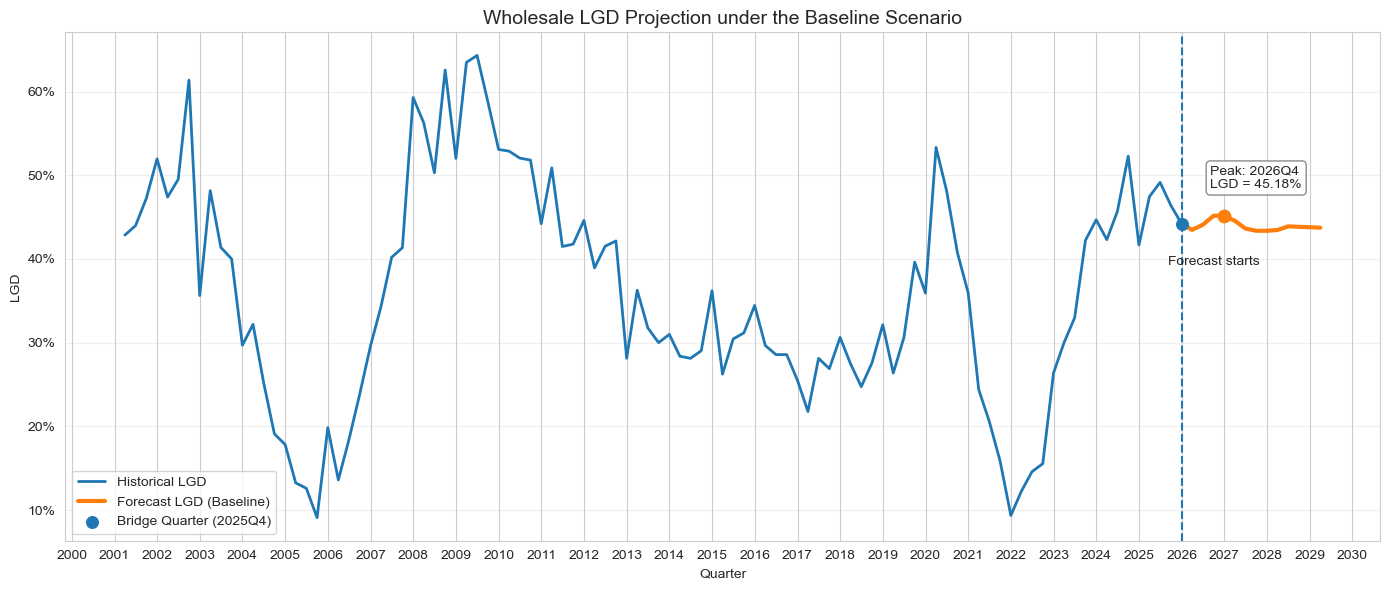

In [23]:
# Baseline Scenario Plot
# historical data
hist = df_model[["Wholesale_LGD"]].copy().reset_index()
hist = hist.rename(columns={hist.columns[0]: "Quarter"})
hist["Quarter"] = hist["Quarter"].astype(str)
hist["Date"] = hist["Quarter"].str.replace("Q1", "-03-31") \
                             .str.replace("Q2", "-06-30") \
                             .str.replace("Q3", "-09-30") \
                             .str.replace("Q4", "-12-31")
hist["Date"] = pd.to_datetime(hist["Date"])

# bridge quarter
bridge_df_base = pd.DataFrame({
    "Quarter": ["2025Q4"],
    "Wholesale_LGD": [lgd_2025q4_hat_base],
    "Date": [pd.Timestamp("2025-12-31")]
})

# forecast path
fcst_plot_base = forecast_lgd_base.copy()
fcst_plot_base["Quarter"] = fcst_plot_base["Quarter"].astype(str)
fcst_plot_base["Date"] = fcst_plot_base["Quarter"].str.replace("Q1", "-03-31") \
                                                .str.replace("Q2", "-06-30") \
                                                .str.replace("Q3", "-09-30") \
                                                .str.replace("Q4", "-12-31")
fcst_plot_base["Date"] = pd.to_datetime(fcst_plot_base["Date"])
fcst_plot_base = fcst_plot_base.rename(columns={"Pred_Wholesale_LGD": "Wholesale_LGD"})

actual_cutoff = pd.Timestamp("2025-09-30")
forecast_start = pd.Timestamp("2025-12-31")

actual_part = hist[hist["Date"] <= actual_cutoff].copy()
historical_extended = pd.concat(
    [actual_part, bridge_df_base[["Date", "Quarter", "Wholesale_LGD"]]],
    ignore_index=True
)
forecast_part = pd.concat(
    [bridge_df_base[["Date", "Quarter", "Wholesale_LGD"]],
     fcst_plot_base[["Date", "Quarter", "Wholesale_LGD"]]],
    ignore_index=True
)

peak_idx = forecast_part["Wholesale_LGD"].idxmax()
peak_row = forecast_part.loc[peak_idx]

plt.figure(figsize=(14, 6))

# historical line
plt.plot(
    historical_extended["Date"],
    historical_extended["Wholesale_LGD"],
    label="Historical LGD",
    linewidth=2
)

# forecast line
plt.plot(
    forecast_part["Date"],
    forecast_part["Wholesale_LGD"],
    label="Forecast LGD (Baseline)",
    linewidth=3
)

# bridge point
plt.scatter(
    bridge_df_base["Date"],
    bridge_df_base["Wholesale_LGD"],
    s=70,
    zorder=5,
    label="Bridge Quarter (2025Q4)"
)

# forecast start line
plt.axvline(x=forecast_start, linestyle="--", linewidth=1.5)

# annotate peak
plt.scatter(peak_row["Date"], peak_row["Wholesale_LGD"], s=80, zorder=6)
plt.annotate(
    f"Peak: {peak_row['Quarter']}\nLGD = {peak_row['Wholesale_LGD']:.2%}",
    xy=(peak_row["Date"], peak_row["Wholesale_LGD"]),
    xytext=(-10, 20),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle="->", lw=1)
)

plt.annotate(
    "Forecast starts",
    xy=(forecast_start, bridge_df_base["Wholesale_LGD"].iloc[0]),
    xytext=(-10, -30),
    textcoords="offset points",
    fontsize=10
)

plt.title("Wholesale LGD Projection under the Baseline Scenario", fontsize=14)
plt.xlabel("Quarter")
plt.ylabel("LGD")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.legend(frameon=True)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Combine baseline and severely adverse forecasts
lgd_all = pd.concat([forecast_lgd_base, forecast_lgd_sev], ignore_index=True)
lgd_all["Quarter"] = lgd_all["Quarter"].astype(str)

# Full audit file
lgd_all.to_csv("./output/wholesale_lgd_forecast_scenarios.csv", index=False)

In [25]:
# Historical actual LGD
hist_export = df_model[["Wholesale_LGD"]].copy().reset_index()
hist_export = hist_export.rename(columns={hist_export.columns[0]: "Quarter"})
hist_export["Quarter"] = hist_export["Quarter"].astype(str)
hist_export["Type"] = "Historical"

# Bridge quarter
bridge_base = pd.DataFrame({
    "Quarter": ["2025Q4"],
    "Wholesale_LGD": [lgd_2025q4_hat_base],
    "Type": ["Bridge"]
})

# Forecast baseline
base_export = forecast_lgd_base[["Quarter", "Pred_Wholesale_LGD"]].copy()
base_export = base_export.rename(columns={"Pred_Wholesale_LGD": "Wholesale_LGD"})
base_export["Quarter"] = base_export["Quarter"].astype(str)
base_export["Type"] = "Forecast"

# Combine baseline file
lgd_baseline_full = pd.concat([hist_export, bridge_base, base_export], ignore_index=True)
lgd_baseline_full["Scenario"] = "Baseline"

# Save
lgd_baseline_full.to_csv("./output/wholesale_lgd_historical_forecast_baseline.csv", index=False)

print(lgd_baseline_full.tail(15))

    Quarter  Wholesale_LGD        Type  Scenario
98   2025Q3       0.464000  Historical  Baseline
99   2025Q4       0.442076      Bridge  Baseline
100  2026Q1       0.434817    Forecast  Baseline
101  2026Q2       0.440842    Forecast  Baseline
102  2026Q3       0.451617    Forecast  Baseline
103  2026Q4       0.451753    Forecast  Baseline
104  2027Q1       0.445575    Forecast  Baseline
105  2027Q2       0.436372    Forecast  Baseline
106  2027Q3       0.433707    Forecast  Baseline
107  2027Q4       0.433675    Forecast  Baseline
108  2028Q1       0.434636    Forecast  Baseline
109  2028Q2       0.438995    Forecast  Baseline
110  2028Q3       0.438405    Forecast  Baseline
111  2028Q4       0.437959    Forecast  Baseline
112  2029Q1       0.437385    Forecast  Baseline


In [26]:
# Bridge quarter
bridge_sev = pd.DataFrame({
    "Quarter": ["2025Q4"],
    "Wholesale_LGD": [lgd_2025q4_hat_sev],
    "Type": ["Bridge"]
})

# Forecast severe adverse
sev_export = forecast_lgd_sev[["Quarter", "Pred_Wholesale_LGD"]].copy()
sev_export = sev_export.rename(columns={"Pred_Wholesale_LGD": "Wholesale_LGD"})
sev_export["Quarter"] = sev_export["Quarter"].astype(str)
sev_export["Type"] = "Forecast"

# Combine severe adverse file
lgd_sev_full = pd.concat([hist_export, bridge_sev, sev_export], ignore_index=True)
lgd_sev_full["Scenario"] = "Severely_Adverse"

# Save
lgd_sev_full.to_csv("./output/wholesale_lgd_historical_forecast_severely_adverse.csv", index=False)

print(lgd_sev_full.tail(15))

    Quarter  Wholesale_LGD        Type          Scenario
98   2025Q3       0.464000  Historical  Severely_Adverse
99   2025Q4       0.442076      Bridge  Severely_Adverse
100  2026Q1       0.543112    Forecast  Severely_Adverse
101  2026Q2       0.705712    Forecast  Severely_Adverse
102  2026Q3       0.758817    Forecast  Severely_Adverse
103  2026Q4       0.794203    Forecast  Severely_Adverse
104  2027Q1       0.819238    Forecast  Severely_Adverse
105  2027Q2       0.802655    Forecast  Severely_Adverse
106  2027Q3       0.769795    Forecast  Severely_Adverse
107  2027Q4       0.744041    Forecast  Severely_Adverse
108  2028Q1       0.721677    Forecast  Severely_Adverse
109  2028Q2       0.673796    Forecast  Severely_Adverse
110  2028Q3       0.610796    Forecast  Severely_Adverse
111  2028Q4       0.539160    Forecast  Severely_Adverse
112  2029Q1       0.461092    Forecast  Severely_Adverse
